# Transformer V2 — Complete CASIA Faculty Demo

This notebook presents the trained **Transformer Forensic Autoencoder V2** using CASIA v2.0. It loads `transformer_v2_final.pth`, explains patch attention, shows the verified 50-epoch training history, reconstructs held-out images, calculates MSE/PSNR/SSIM, and visualizes attention and reconstruction differences.

**Reconstruction error and attention are exploratory forensic indicators—not tampering probabilities or proof of manipulation. No retraining occurs.**

In [1]:
# Imports, reproducibility, and project discovery
from pathlib import Path
import json, random, sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from PIL import Image
from IPython.display import display
SEED=42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
candidates=[Path.cwd(),*Path.cwd().parents,Path('/content/Digital-Evidence-GenAI'),Path('/content/AI-Digital-Evidence-Intelligence-Platform')]
PROJECT_ROOT=next((p.resolve() for p in candidates if (p/'src'/'transformer.py').is_file()),None)
if PROJECT_ROOT is None: raise FileNotFoundError('Run this notebook inside the project repository.')
sys.path.insert(0,str(PROJECT_ROOT/'src'))
DEVICE=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Project:',PROJECT_ROOT); print('Device:',torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'); print('Mode: trained-checkpoint demonstration (no retraining)')

Project: C:\Users\Chetanraje\Desktop\GAA\Digital_Evidence
Device: CPU
Mode: trained-checkpoint demonstration (no retraining)


## 1. CASIA dataset and fixed manifests

- Total images: 12,614
- Authentic: 7,491
- Tampered: 5,123
- RGB → 128×128 → tensor in `[0,1]`
- Seed: 42
- Ground-truth masks are excluded from model input.

The repository's canonical 70/15/15 manifests are reused. Labels are retained only for exploratory comparison.

In [2]:
frames={name:pd.read_csv(PROJECT_ROOT/'data'/'splits'/f'{name}.csv') for name in ('train','validation','test')}
rows=[]
for name,frame in frames.items(): rows.append({'Split':name.title(),'Total':len(frame),'Authentic':int((frame.label==0).sum()),'Tampered':int((frame.label==1).sum())})
display(pd.DataFrame(rows)); print('Canonical total:',sum(row['Total'] for row in rows))

,Split,Total,Authentic,Tampered
0,Train,8830,5244,3586
1,Validation,1892,1124,768
2,Test,1892,1123,769


Canonical total: 12614


## 2. Transformer V2 architecture

```text
3×128×128 image
→ 64 non-overlapping 16×16 patches
→ 64×256 embedded tokens + learned positions
→ 4 Transformer encoder layers (8 attention heads)
→ 256-dimensional global representation for analysis
→ 2 Transformer decoder layers using all 64 encoded tokens
→ 64 reconstructed RGB patches
→ 3×128×128 Sigmoid reconstruction
```

Keeping all encoded patch tokens in the decoder preserves spatial information better than reconstructing from only one global vector.

In [3]:
from transformer import TransformerForensicAutoencoder
CHECKPOINT=PROJECT_ROOT/'checkpoints'/'transformer_v2_final.pth'
checkpoint=torch.load(CHECKPOINT,map_location=DEVICE,weights_only=True)
model=TransformerForensicAutoencoder(image_size=checkpoint['image_size'],patch_size=checkpoint['patch_size'],embed_dim=checkpoint['embed_dim'],num_heads=checkpoint['num_heads'],encoder_layers=checkpoint['encoder_layers'],decoder_layers=checkpoint['decoder_layers'],ff_dim=checkpoint['ff_dim']).to(DEVICE)
incompatible=model.load_state_dict(checkpoint['model_state_dict'],strict=True); model.eval()
configuration={key:checkpoint[key] for key in ('architecture','image_size','patch_size','num_patches','embed_dim','num_heads','encoder_layers','decoder_layers','ff_dim')}
display(pd.DataFrame(configuration.items(),columns=['Property','Value']))
print('Parameters:',f'{sum(p.numel() for p in model.parameters()):,}'); print('Strict loading: PASS'); print('Missing/unexpected keys:',incompatible.missing_keys,incompatible.unexpected_keys)

,Property,Value
0,architecture,Transformer Forensic Autoencoder V2
1,image_size,128
2,patch_size,16
3,num_patches,64
4,embed_dim,256
5,num_heads,8
6,encoder_layers,4
7,decoder_layers,2
8,ff_dim,512


Parameters: 3,591,168
Strict loading: PASS
Missing/unexpected keys: [] []


## 3. Training configuration and objective

- Authentic-only reconstruction learning in the source experiment
- Epochs: 50
- Batch size: 64
- Optimizer: AdamW
- Learning rate: 0.0001
- Weight decay: 0.00001
- Loss: MSE
- Scheduler: ReduceLROnPlateau
- Best checkpoint selected by validation MSE

In [4]:
metadata={key:checkpoint.get(key) for key in ('epoch','train_mse','validation_mse','anomaly_threshold','roc_auc','accuracy','precision','recall','f1_score','balanced_accuracy')}
display(pd.DataFrame(metadata.items(),columns=['Checkpoint field','Value']))
print('Checkpoint:',CHECKPOINT)

,Checkpoint field,Value
0,epoch,50.000000
1,train_mse,0.002569
2,validation_mse,0.002060
3,anomaly_threshold,0.004404
4,roc_auc,0.545534
5,accuracy,0.240717
6,precision,0.892340
7,recall,0.084130
8,f1_score,0.153764
9,balanced_accuracy,0.518954


Checkpoint: C:\Users\Chetanraje\Desktop\GAA\Digital_Evidence\checkpoints\transformer_v2_final.pth


## 4. Verified training and validation loss curves

,epoch,train_mse,validation_mse,learning_rate
45,46,0.002720,0.002166,0.0001
46,47,0.002716,0.002130,0.0001
47,48,0.002624,0.002111,0.0001
48,49,0.002600,0.002094,0.0001
49,50,0.002569,0.002060,0.0001


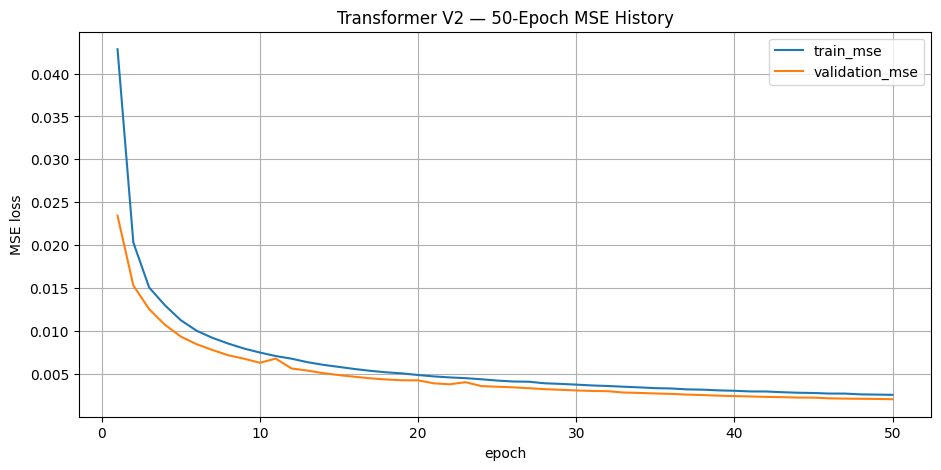

Epochs: 50
First/final training MSE: 0.04283 0.002569
Best epoch/MSE: 50 0.00206


In [5]:
history=pd.read_csv(PROJECT_ROOT/'results'/'transformer_v2_training_history.csv'); display(history.tail())
ax=history.plot(x='epoch',y=['train_mse','validation_mse'],figsize=(11,5),grid=True,title='Transformer V2 — 50-Epoch MSE History'); ax.set_ylabel('MSE loss'); plt.show()
best=history.loc[history.validation_mse.idxmin()]; print('Epochs:',len(history)); print('First/final training MSE:',history.train_mse.iloc[0],history.train_mse.iloc[-1]); print('Best epoch/MSE:',int(best.epoch),best.validation_mse)

## 5. Source evaluation provenance

The source notebook reports validation reconstruction **PSNR 27.5793 dB** and **SSIM 0.8498**. Its final exported checkpoint reports reconstruction-error ROC-AUC **0.5455** and threshold **0.0044039**.

The source notebook's forensic evaluation used 6,248 images (1,125 authentic and all 5,123 tampered images), which is **not the repository's canonical 1,892-image held-out test manifest**. These stored classification values are therefore shown as checkpoint provenance, not relabeled as canonical test results.

## 6. Load balanced examples from the canonical held-out test split

In [6]:
from ae_dataset import AutoencoderImageDataset
dataset=AutoencoderImageDataset(PROJECT_ROOT/'data'/'splits'/'test.csv',128)
selected=[]
for index,record in enumerate(dataset.records):
 label=int(record['label'])
 if sum(int(item[1])==label for item in selected)<3: selected.append((index,label))
 if len(selected)==6: break
images=torch.stack([dataset[index]['image'] for index,_ in selected]).to(DEVICE)
labels=[label for _,label in selected]
with torch.no_grad(): reconstructed,latent,attention_maps=model(images)
print('Input:',tuple(images.shape)); print('Reconstruction:',tuple(reconstructed.shape)); print('Latent:',tuple(latent.shape)); print('Attention layers:',len(attention_maps),'| final map:',tuple(attention_maps[-1].shape))

Input: (6, 3, 128, 128)
Reconstruction: (6, 3, 128, 128)
Latent: (6, 256)
Attention layers: 4 | final map: (6, 64, 64)


## 7. Original versus reconstructed images and per-image metrics

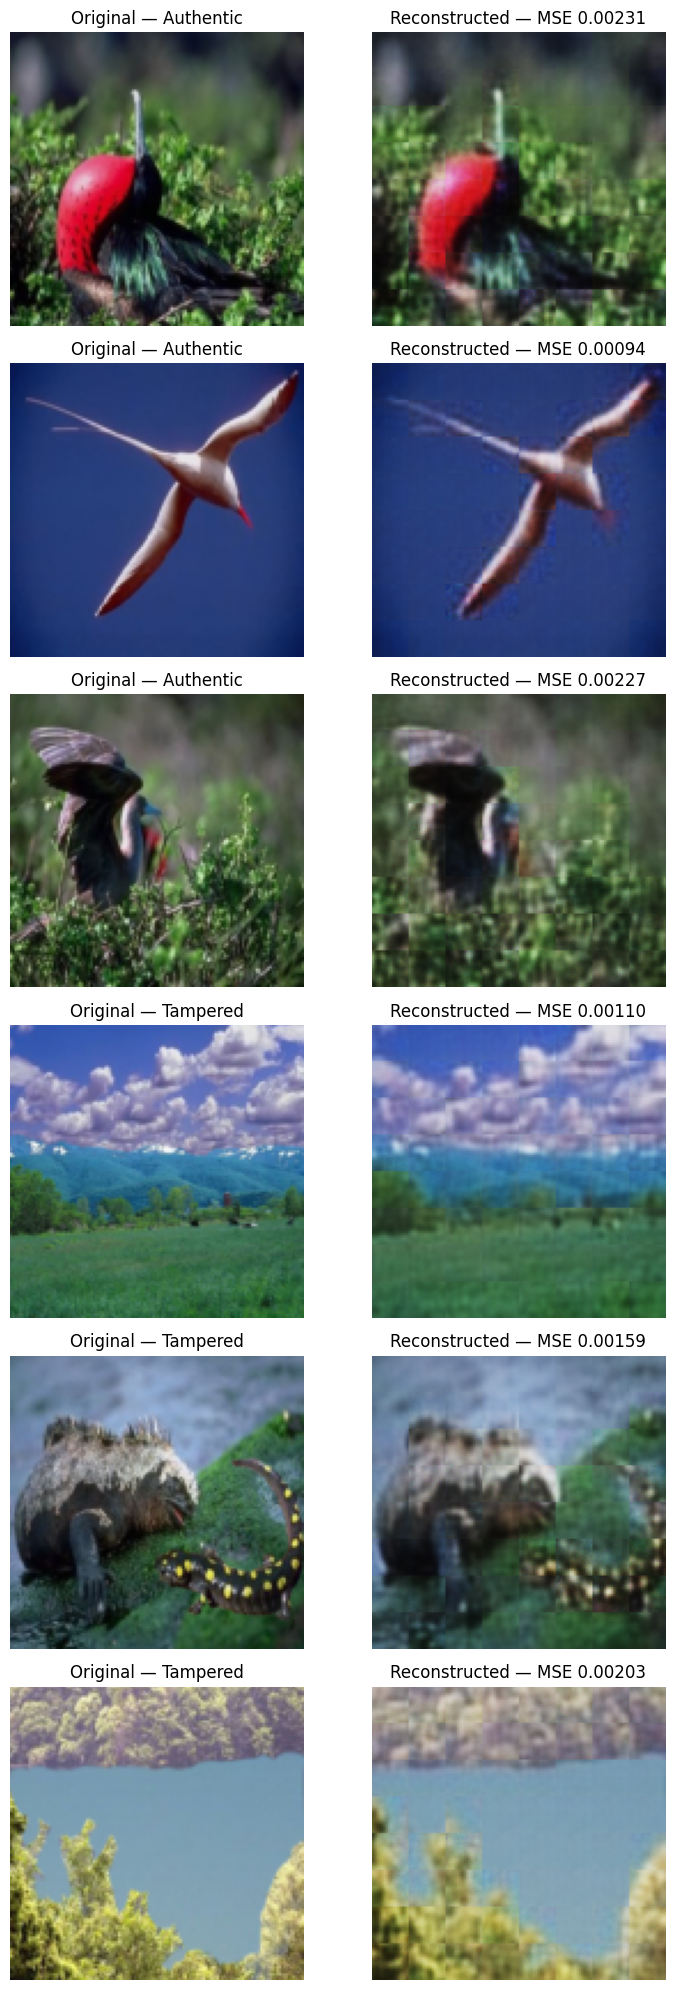

,Class,MSE,PSNR,SSIM
0,Authentic,0.002311,26.361315,0.849112
1,Authentic,0.000936,30.287997,0.902158
2,Authentic,0.002272,26.436365,0.837555
3,Tampered,0.001096,29.600453,0.831673
4,Tampered,0.001585,27.998700,0.849847
5,Tampered,0.002029,26.927986,0.806743


In [7]:
from skimage.metrics import structural_similarity
records=[]; fig,axes=plt.subplots(6,2,figsize=(8,20))
for i,label in enumerate(labels):
 original=images[i].cpu().permute(1,2,0).numpy(); output=reconstructed[i].cpu().permute(1,2,0).numpy().clip(0,1); mse=float(np.mean((original-output)**2)); psnr=float(-10*np.log10(max(mse,1e-12))); ssim=float(structural_similarity(original,output,channel_axis=2,data_range=1.0)); records.append({'Class':'Authentic' if label==0 else 'Tampered','MSE':mse,'PSNR':psnr,'SSIM':ssim}); axes[i,0].imshow(original); axes[i,0].set_title('Original — '+records[-1]['Class']); axes[i,1].imshow(output); axes[i,1].set_title(f'Reconstructed — MSE {mse:.5f}'); axes[i,0].axis('off'); axes[i,1].axis('off')
plt.tight_layout(); plt.show(); display(pd.DataFrame(records))

## 8. Reconstruction-error indicator

The saved threshold is the 95th percentile of authentic validation reconstruction errors. A value above it can be flagged for additional review, but it is **not a tampering probability** and does not confirm manipulation.

In [8]:
threshold=float(checkpoint['anomaly_threshold']); indicators=pd.DataFrame(records); indicators['Reference threshold']=threshold; indicators['Exploratory indicator']=np.where(indicators.MSE>threshold,'Above reference range','Within reference range'); display(indicators[['Class','MSE','Reference threshold','Exploratory indicator']]); print('Checkpoint ROC-AUC:',checkpoint['roc_auc'],'— limited separation')

,Class,MSE,Reference threshold,Exploratory indicator
0,Authentic,0.002311,0.004404,Within reference range
1,Authentic,0.000936,0.004404,Within reference range
2,Authentic,0.002272,0.004404,Within reference range
3,Tampered,0.001096,0.004404,Within reference range
4,Tampered,0.001585,0.004404,Within reference range
5,Tampered,0.002029,0.004404,Within reference range


Checkpoint ROC-AUC: 0.5455342572711303 — limited separation


## 9. Reconstruction difference maps

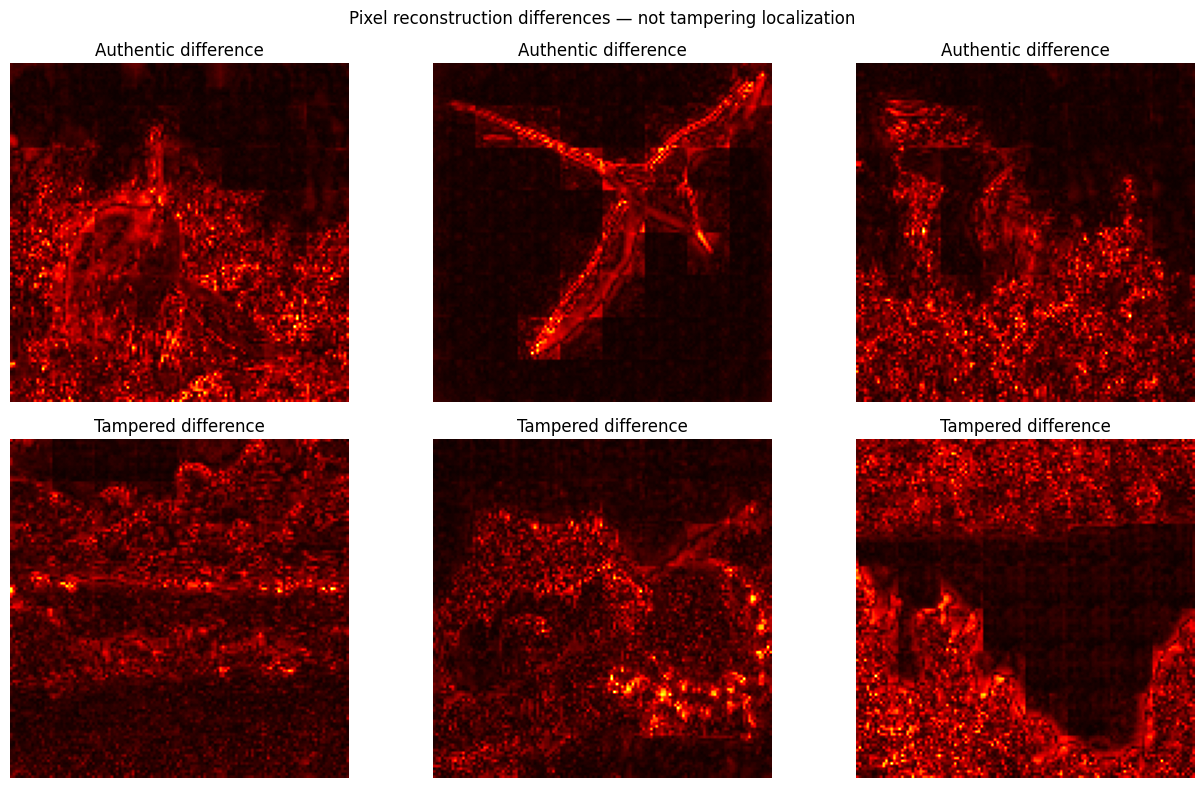

In [9]:
fig,axes=plt.subplots(2,3,figsize=(13,8))
for ax,i in zip(axes.flat,range(6)):
 difference=torch.mean(torch.abs(images[i]-reconstructed[i]),dim=0).cpu(); ax.imshow(difference,cmap='hot'); ax.set_title(('Authentic' if labels[i]==0 else 'Tampered')+' difference'); ax.axis('off')
plt.suptitle('Pixel reconstruction differences — not tampering localization'); plt.tight_layout(); plt.show()

## 10. Patch-attention visualization

Attention describes relationships learned between patches. It must not be interpreted as definitive tampering localization.

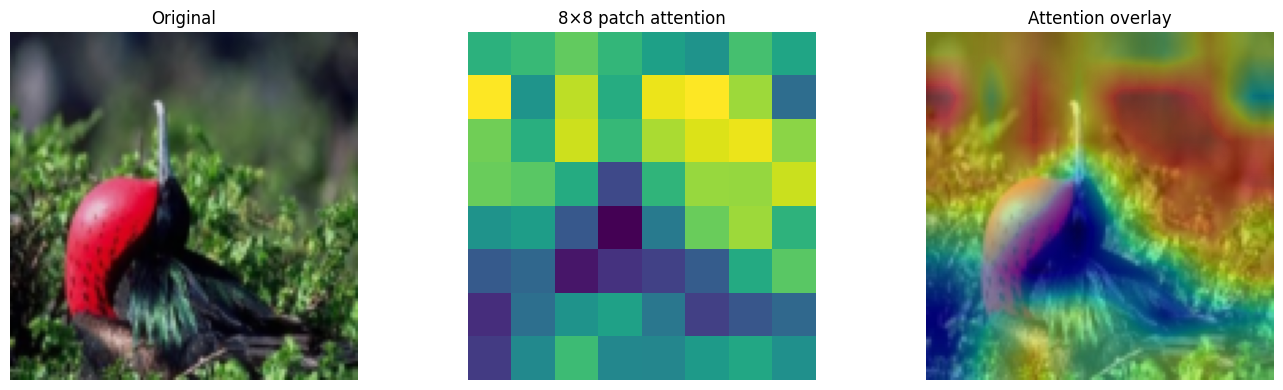

In [10]:
index=0; matrix=attention_maps[-1][index].cpu().numpy(); patch_attention=matrix.mean(axis=0).reshape(8,8); patch_attention=(patch_attention-patch_attention.min())/(np.ptp(patch_attention)+1e-8); original=images[index].cpu().permute(1,2,0).numpy(); overlay=np.array(Image.fromarray((patch_attention*255).astype(np.uint8)).resize((128,128),Image.Resampling.BILINEAR))/255
fig,axes=plt.subplots(1,3,figsize=(14,4)); axes[0].imshow(original); axes[0].set_title('Original'); axes[1].imshow(patch_attention,cmap='viridis'); axes[1].set_title('8×8 patch attention'); axes[2].imshow(original); axes[2].imshow(overlay,cmap='jet',alpha=.45); axes[2].set_title('Attention overlay'); [ax.axis('off') for ax in axes]; plt.tight_layout(); plt.show()

## 11. Faculty summary

In [11]:
print('Transformer V2 checkpoint:',CHECKPOINT)
print('Epochs:',checkpoint['epoch']); print('Final training MSE:',checkpoint['train_mse']); print('Best validation MSE:',checkpoint['validation_mse']); print('Source validation PSNR/SSIM: 27.5793 dB / 0.8498'); print('Reference threshold:',checkpoint['anomaly_threshold']); print('Source reconstruction-error ROC-AUC:',checkpoint['roc_auc']); print('Conclusion: useful reconstruction and attention analysis, but reconstruction error alone is not reliable tampering detection.')

Transformer V2 checkpoint: C:\Users\Chetanraje\Desktop\GAA\Digital_Evidence\checkpoints\transformer_v2_final.pth
Epochs: 50
Final training MSE: 0.002568504736168174
Best validation MSE: 0.002060044957842264
Source validation PSNR/SSIM: 27.5793 dB / 0.8498
Reference threshold: 0.004403905477374792
Source reconstruction-error ROC-AUC: 0.5455342572711303
Conclusion: useful reconstruction and attention analysis, but reconstruction error alone is not reliable tampering detection.


## 12. Conclusion and limitations

- Transformer V2 reconstructs images using full spatial patch tokens.
- Self-attention provides an interpretable patch-relationship visualization.
- The saved ROC-AUC is close to random ranking, so forensic separation is limited.
- Attention and bright difference-map regions do not prove localization of manipulation.
- CASIA is the primary dataset and cross-dataset generalization remains limited.
- This is an academic research prototype, not a production or legal forensic decision system.